# EDA: E-Commerce com 1 milhão de dados

Análise exploratória de dados com mais de **1 milhão de transações** de uma loja de varejo global. Os dados vão de 2024 até 2026.
É importante lembrar que é uma base de dados **sintética**, isto é, dados gerados artificialmente para estudo/prática de análise de dados.

**Importante**: Como o arquivo .csv excede os 100mbs, então não foi possível envia-lo ao GitHub. Por esse motivo, os dados deverão ser
baixados manualmente!

**Dataset**: [Kaggle](https://www.kaggle.com/datasets/akrambelha/global-e-commerce-dataset-1m-records-20242026)

## Objetivos:
- **Entender a saúde financeira**
- **Mapear sazonalidade**
- **Analisar devoluções**
- **Gerar insights**

## Sumário

- [1. Carregamento e limpeza](#limpeza)
- [2. KPIs e tendências](#kpis)
- [3. Análises Temporais](#temporal)
- [4. Perfil do Cliente](#perfil)
- [5. Produtos & Devoluções](#produtos)
- [6. Entrega & Experiência](#entrega)
- [7. Pagamento & Geografia](#pagamento)
- [8. Insights e Recomendações](#insights)
- [9. Encerramento](#encerramento)

In [3]:
# Importações
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)
pd.set_option('display.width', 300)
pd.set_option('display.max_colwidth', 50)

<div id="limpeza"></div>

## 1. Carregamento e limpeza

In [17]:
df = pd.read_csv('data.csv')

# Quantidade de linhas e colunas
print(f"Linhas: {len(df):,} | Colunas: {len(df.columns)}")

# Datatypes
print(f"\nDataset:\n\n{df.dtypes}")

# Nulos
print(f"\nNulos:\n\n{df.isnull().sum()}")

# Clientes únicos
print(f"\nClientes únicos:\n\n{df['customer_id'].dropna().nunique():,}")

# Países
print(f"\nPaíses:\n\n{df['country'].nunique()}")

df['order_date'] = pd.to_datetime(df['order_date'])

df.head(3)

Linhas: 1,000,123 | Colunas: 62

Dataset:

order_id                        str
order_date                      str
order_year                    int64
order_month                   int64
order_day                     int64
order_hour                    int64
order_minute                  int64
order_second                  int64
is_weekend                      str
order_status                    str
return_reason                   str
customer_id                     str
customer_name                   str
gender                          str
age                           int64
customer_segment                str
country                         str
city                            str
customer_loyalty_score      float64
total_orders_by_customer      int64
account_creation_date           str
product_id                      str
product_name                    str
category                        str
sub_category                    str
brand                           str
product_rating_avg   

,order_id,order_date,order_year,order_month,order_day,order_hour,order_minute,order_second,is_weekend,order_status,return_reason,customer_id,customer_name,gender,age,customer_segment,country,city,customer_loyalty_score,total_orders_by_customer,account_creation_date,product_id,product_name,category,sub_category,brand,product_rating_avg,product_reviews_count,stock_quantity,unit_price_usd,quantity,discount_percent,discount_amount_usd,total_price_usd,cost_usd,profit_usd,tax_usd,currency,payment_method,payment_status,installment_plan,shipping_method,shipping_cost_usd,delivery_days,shipping_country,warehouse_location,delivery_status,rating,review_sentiment,customer_feedback,coupon_used,coupon_code,campaign_source,device_type,traffic_source,session_duration_minutes,pages_visited,abandoned_cart_before,fraud_risk_score,profit_margin_percent,order_priority,support_ticket_created
0,ORD-XAJI0,2024-10-14 11:20:05.496679,2024,10,14,11,20,5,No,Completed,NaN,CUS-6DPBH,Drew Warren,Male,53,Regular,Netherlands,Utrecht,22.0,38,2022-04-23,PRD-1FPK,Coffee Maker Automatic,Home,Kitchen,Nike,3.2,3112,99,120.51,3,10,36.15,325.38,232.14,93.24,28.14,USD,Apple Pay,Paid,No,Economy,1.97,5,Netherlands,UK,In Transit,3,Neutral,NaN,Yes,CPN-ZBI,Email,Mobile,Search,52.1,13,No,45.3,28.66,Medium,Yes
1,ORD-NHJ7X,2024-10-21 00:49:44.681065,2024,10,21,0,49,44,No,Completed,NaN,CUS-G0FN9,Victor Sullivan,Male,61,Regular,United States,Los Angeles,82.2,21,2022-08-22,PRD-C6UZ,Yoga Mat Non-Slip,Health,Supplements,Asus,3.8,3758,146,60.33,2,15,18.10,102.56,67.78,34.78,8.96,USD,Bank Transfer,Paid,Yes,Next Day,5.48,3,United States,UK,Delivered,1,Negative,Good value for money,Yes,CPN-W2P,Google Ads,Desktop,Referral,36.2,15,No,97.1,33.91,Low,Yes
2,ORD-YTJXE,2025-03-17 19:49:36.983317,2025,3,17,19,49,36,No,Completed,NaN,CUS-Q85JS,Jason Garcia,Male,50,VIP,France,Nice,60.9,10,2024-08-04,PRD-T2TA,Blender 1000W,Home,Furniture,Asus,3.0,2973,899,295.89,3,0,0.00,887.67,419.22,468.45,69.56,USD,Credit Card,Paid,No,Economy,20.40,13,France,UK,In Transit,2,Negative,Highly recommended,Yes,CPN-J5P,Facebook,Tablet,Search,43.1,13,No,43.8,52.77,High,No


### O que podemos extrair dessa base de dados?
1 - separação de KPIs por ano, semestre, mes, semana...

2 - Situação do pedido (completado ou não completado)

3 - Clientes mais recorrentes

4 - Gênero mais recorrente

5 - Descobrir a densidade de faixa etária para criação segmentada de marketing

6 - Categoria de clientes (Vip ou normal)

7 - Países que mais compram

8 - Lealdade dos clientes

9 - Categorias de produtos que mais vendem

10 - Média de reviews para cada produto/marca

11 - Método de pagamentos mais recorrente

12 - Método de envio mais recorrente

13 - Correlação entre tempo de entrega e review

14 - Correlação com o dispositivo que o cliente usa

entre muitas outras... (itens 3, 7, 8, 11, 12 e 13 são atendidos nas seções 4 a 7)

<div id="kpis"></div>

## 2. Kpis

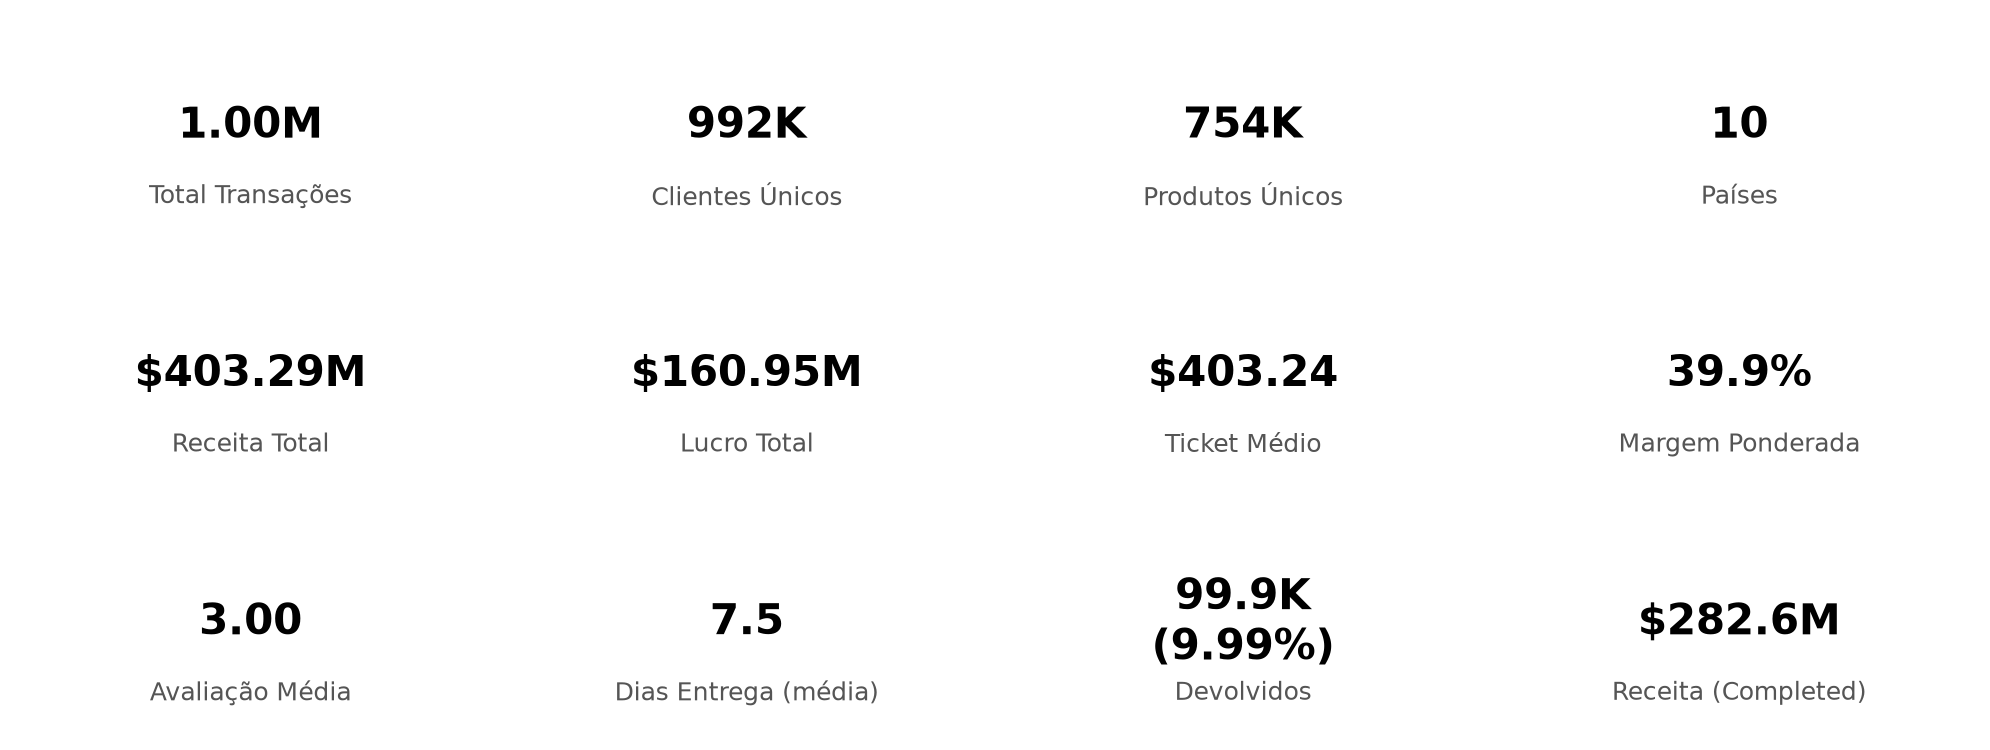

In [18]:
total_transacoes = df.shape[0]
clientes_unicos = df['customer_id'].nunique()
produtos_unicos = df['product_id'].nunique()
paises = df['country'].nunique()
categorias = df['category'].nunique()
receita_total = df['total_price_usd'].sum()
lucro_total = df['profit_usd'].sum()
ticket_medio = df['total_price_usd'].mean()
margem_ponderada = df['profit_usd'].sum() / df['total_price_usd'].sum() * 100
media_avaliacao = df['rating'].mean()
media_tempo_entrega = df['delivery_days'].mean()

completed_count = df[(df['order_status'] == 'Completed')].shape[0]
completed_pct = (df['order_status'] == 'Completed').mean() * 100
returned_count = df[(df['order_status'] == 'Returned')].shape[0]
returned_pct = (df['order_status'] == 'Returned').mean() * 100

receita_completed = df.loc[df['order_status'] == 'Completed', 'total_price_usd'].sum()

coupon_used_pct = (df['coupon_used'] == 'Yes').mean() * 100
abandoned_cart_pct = (df['abandoned_cart_before'] == 'Yes').mean() * 100

fig, axes = plt.subplots(3, 4, figsize=(20, 8))
axes = axes.flatten()

kpis = [
    (f'{total_transacoes/1_000_000:.2f}M', 'Total Transações'),
    (f'{clientes_unicos/1_000:.0f}K', 'Clientes Únicos'),
    (f'{produtos_unicos/1_000:.0f}K', 'Produtos Únicos'),
    (f'{paises}', 'Países'),
    (f'${receita_total/1_000_000:.2f}M', 'Receita Total'),
    (f'${lucro_total/1_000_000:.2f}M', 'Lucro Total'),
    (f'${ticket_medio:,.2f}', 'Ticket Médio'),
    (f'{margem_ponderada:.1f}%', 'Margem Ponderada'),
    (f'{media_avaliacao:.2f}', 'Avaliação Média'),
    (f'{media_tempo_entrega:.1f}', 'Dias Entrega (média)'),
    (f'{returned_count/1_000:.1f}K\n({returned_pct:.2f}%)', 'Devolvidos'),
    (f'${receita_completed/1_000_000:.1f}M', 'Receita (Completed)'),
]

for ax, (valor, titulo) in zip(axes, kpis):
    ax.text(0.5, 0.5, valor, fontsize=30, fontweight='bold', ha='center', va='center')
    ax.text(0.5, 0.2, titulo, fontsize=18, ha='center', va='center', color='#555555')
    ax.set_axis_off()
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['top'].set_linewidth(0.5)
    ax.spines['right'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)
    ax.spines['left'].set_linewidth(0.5)
    ax.set_facecolor('#FAFAFA')

# Esconde células vazias
for j in range(len(kpis), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

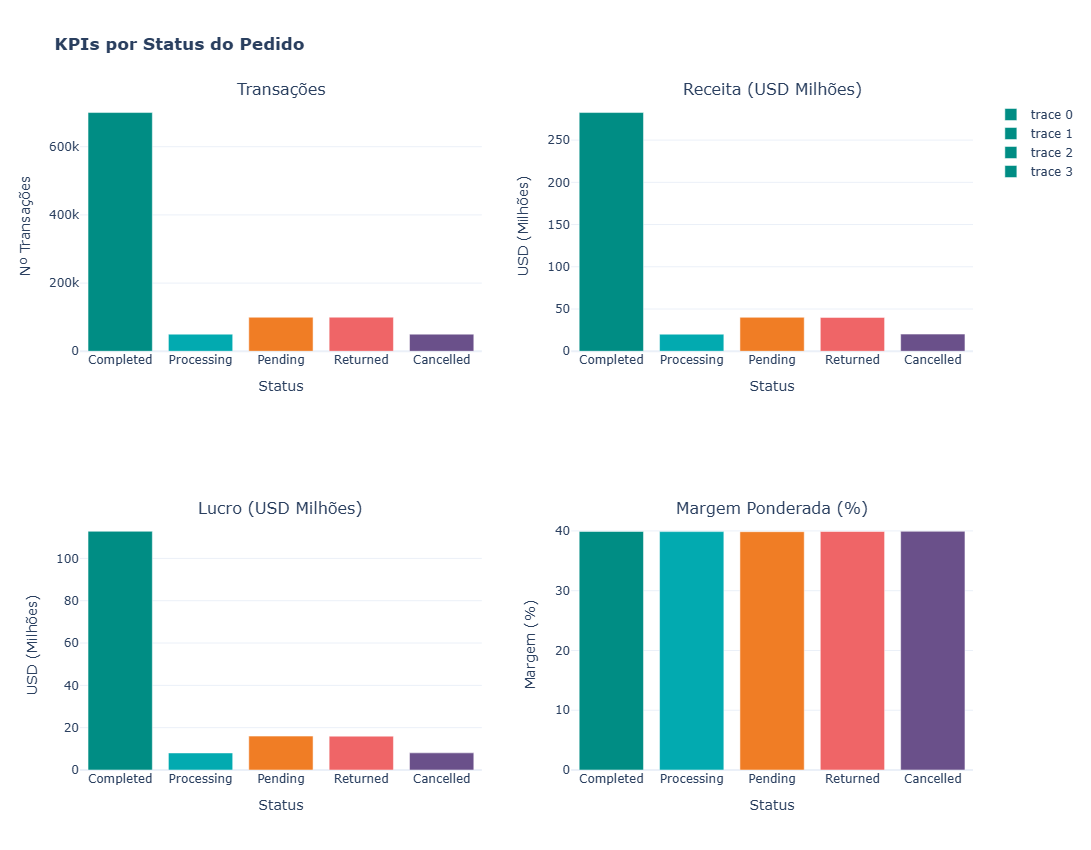

Completed = 70.0% das transações e US$282.6M de receita


In [19]:
# KPIs por status do pedido
status = df.groupby('order_status').agg(
    transacoes=('order_id', 'count'),
    receita=('total_price_usd', 'sum'),
    lucro=('profit_usd', 'sum')
).reindex(['Completed', 'Processing', 'Pending', 'Returned', 'Cancelled'])

cores_status = {
    'Completed': '#008D84',
    'Processing': '#02AAB0',
    'Pending': '#F07D25',
    'Returned': '#EF6567',
    'Cancelled': '#6A508A'
}

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Transações', 'Receita (USD Milhões)',
                    'Lucro (USD Milhões)', 'Margem Ponderada (%)'),
    vertical_spacing=0.25
)

x = status.index
fig.add_trace(go.Bar(x=x, y=status['transacoes'],
                     marker_color=[cores_status[s] for s in x]), row=1, col=1)
fig.add_trace(go.Bar(x=x, y=status['receita'] / 1e6,
                     marker_color=[cores_status[s] for s in x]), row=1, col=2)
fig.add_trace(go.Bar(x=x, y=status['lucro'] / 1e6,
                     marker_color=[cores_status[s] for s in x]), row=2, col=1)
fig.add_trace(go.Bar(x=x, y=status['lucro'] / status['receita'] * 100,
                     marker_color=[cores_status[s] for s in x]), row=2, col=2)

fig.update_layout(
    title='<b>KPIs por Status do Pedido</b>',
    template='plotly_white',
    height=850
)
fig.update_xaxes(title_text='Status', row=1, col=1)
fig.update_yaxes(title_text='Nº Transações', row=1, col=1)
fig.update_xaxes(title_text='Status', row=1, col=2)
fig.update_yaxes(title_text='USD (Milhões)', row=1, col=2)
fig.update_xaxes(title_text='Status', row=2, col=1)
fig.update_yaxes(title_text='USD (Milhões)', row=2, col=1)
fig.update_xaxes(title_text='Status', row=2, col=2)
fig.update_yaxes(title_text='Margem (%)', row=2, col=2)
fig.show()

print(f"Completed = {status['transacoes'].loc['Completed'] / len(df) * 100:.1f}% das transações e US${status['receita'].loc['Completed'] / 1e6:.1f}M de receita")

<div id="temporal"></div>

## 3. Análises Temporal

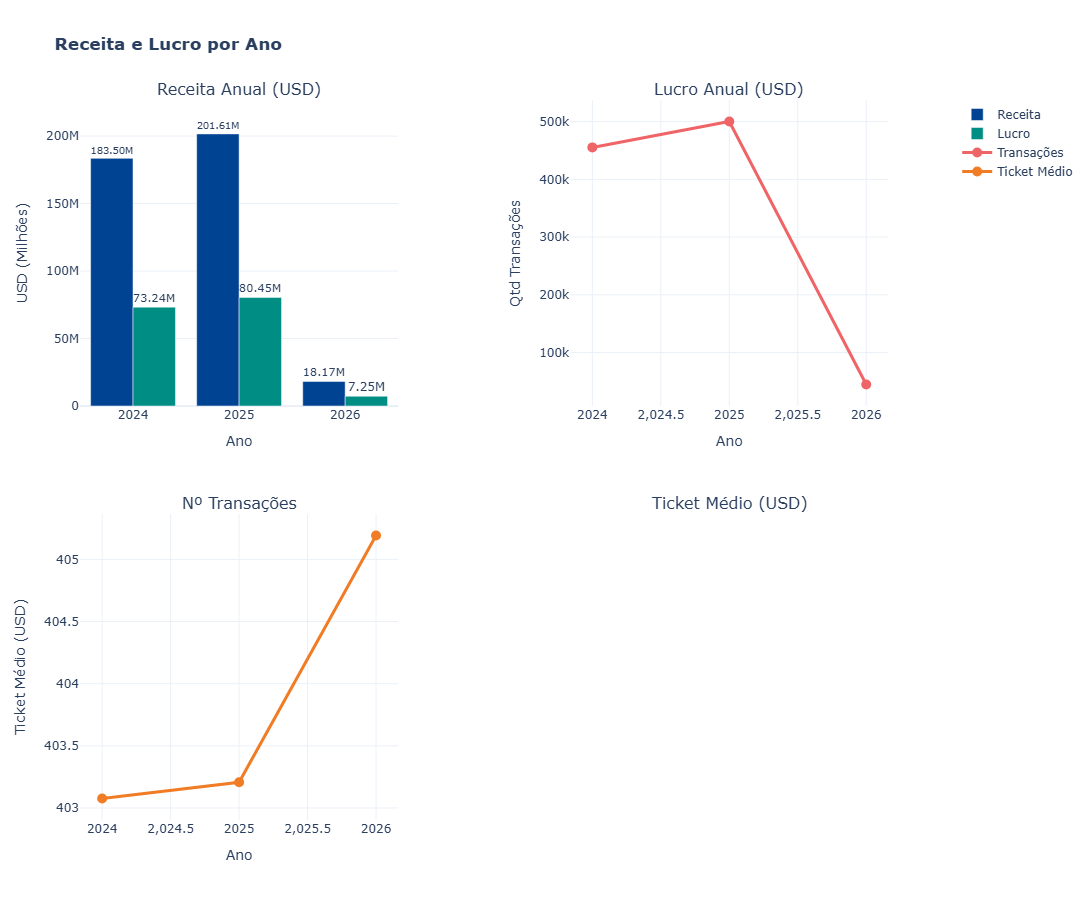

In [7]:
# Receita e lucro por ano

receita_ano = df.groupby('order_year').agg(
    receita=('total_price_usd', 'sum'),
    lucro=('profit_usd', 'sum'),
    transacoes=('order_id', 'count'),
    ticket_medio=('total_price_usd', 'mean')
).reset_index()

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Receita Anual (USD)', 'Lucro Anual (USD)',
                    'Nº Transações', 'Ticket Médio (USD)'),
    vertical_spacing=0.15,
    specs=[[{"secondary_y": True}, {"secondary_y": False}],
           [{"secondary_y": False}, {"secondary_y": False}]
          ]
)

# Receita por ano (barras)
fig.add_trace(
    go.Bar(x=receita_ano['order_year'], y=receita_ano['receita'],
          name='Receita', marker_color='#004393', text=receita_ano['receita'] / 1e6,
          texttemplate='%{text:.2f}M', textposition='outside'),
    row=1, col=1
)
fig.add_trace(
    go.Bar(x=receita_ano['order_year'], y=receita_ano['lucro'],
          name='Lucro', marker_color='#008D84', text=receita_ano['lucro'] / 1e6,
          texttemplate='%{text:.2f}M', textposition='outside'),
    row=1, col=1
)

# Transações por ano (linha)
fig.add_trace(
    go.Scatter(x=receita_ano['order_year'], y=receita_ano['transacoes'],
              mode='lines+markers', name='Transações',
              line=dict(color='#EF6567', width=3),
              marker=dict(size=10)),
    row=1, col=2
)

# Ticket médio por ano (linha)
fig.add_trace(
    go.Scatter(x=receita_ano['order_year'], y=receita_ano['ticket_medio'],
              mode='lines+markers', name='Ticket Médio',
              line=dict(color='#F07D25', width=3),
              marker=dict(size=10)),
    row=2, col=1
)

fig.update_layout(
    title='<b>Receita e Lucro por Ano</b>',
    height=900,
    showlegend=True,
    template='plotly_white'
)
fig.update_xaxes(title_text='Ano', row=1, col=1)
fig.update_yaxes(title_text='USD (Milhões)', row=1, col=1)
fig.update_xaxes(title_text='Ano', row=1, col=2)
fig.update_yaxes(title_text='Qtd Transações', row=1, col=2)
fig.update_xaxes(title_text='Ano', row=2, col=1)
fig.update_yaxes(title_text='Ticket Médio (USD)', row=2, col=1)
fig.show()


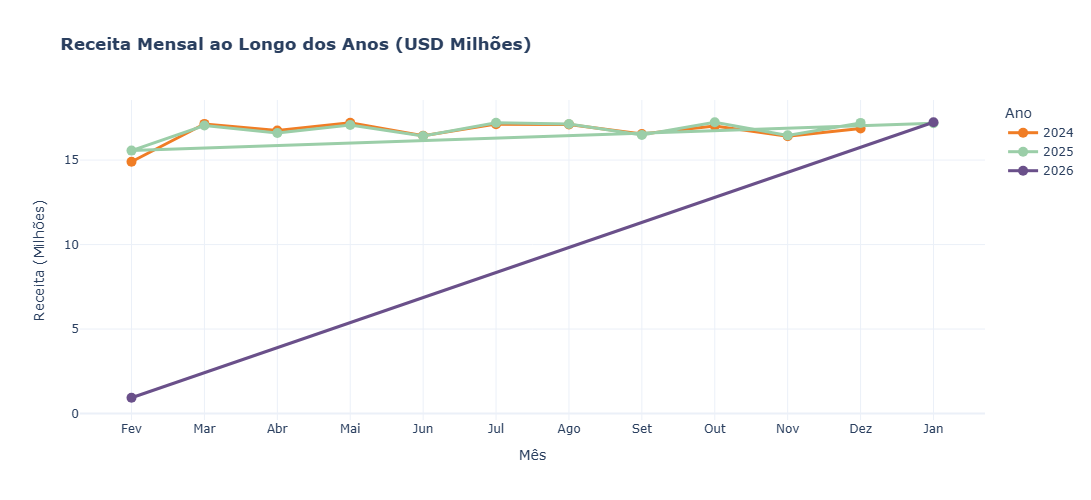

In [8]:
# Sazonalidade

receita_mensal = df.groupby(['order_year', 'order_month']).agg(
    receita=('total_price_usd', 'sum'),
    lucro=('profit_usd', 'sum'),
    transacoes=('order_id', 'count')
).reset_index()

receita_mensal['month_name'] = receita_mensal['order_month'].apply(
    lambda m: {1:'Jan', 2:'Fev', 3:'Mar', 4:'Abr', 5:'Mai', 6:'Jun',
              7:'Jul', 8:'Ago', 9:'Set', 10:'Out', 11:'Nov', 12:'Dez'}[m]
)

meses_mapeamento = {'Jan':1, 'Fev':2, 'Mar':3, 'Abr':4, 'Mai':5, 'Jun':6,
              'Jul':7, 'Ago':8, 'Set':9, 'Out':10, 'Nov':11, 'Dez':12}
receita_mensal['month_order'] = receita_mensal['month_name'].map(meses_mapeamento)

cores_ano = {
    2024: '#F07D25',  # Laranja
    2025: '#9BCEA8',  # Verde claro
    2026: '#6A508A'   # Roxo
}

mes_anos = set(receita_mensal['order_year'])
fig = go.Figure()
for idx, ano in enumerate(sorted(mes_anos)):
    dados_ano = receita_mensal[receita_mensal['order_year'] == ano].sort_values('month_order')
    fig.add_trace(go.Scatter(
        x=dados_ano['month_name'],
        y=dados_ano['receita'] / 1e6,
        mode='lines+markers',
        name=str(ano),
        line=dict(width=3, color=cores_ano.get(ano, '#02AAB0')),  # Usa a cor definida
        marker=dict(size=10)
    ))

fig.update_layout(
    title='<b> Receita Mensal ao Longo dos Anos (USD Milhões)</b>',
    xaxis_title='Mês',
    yaxis_title='Receita (Milhões)',
    template='plotly_white',
    height=500,
    legend_title_text='Ano'
)

fig.show()

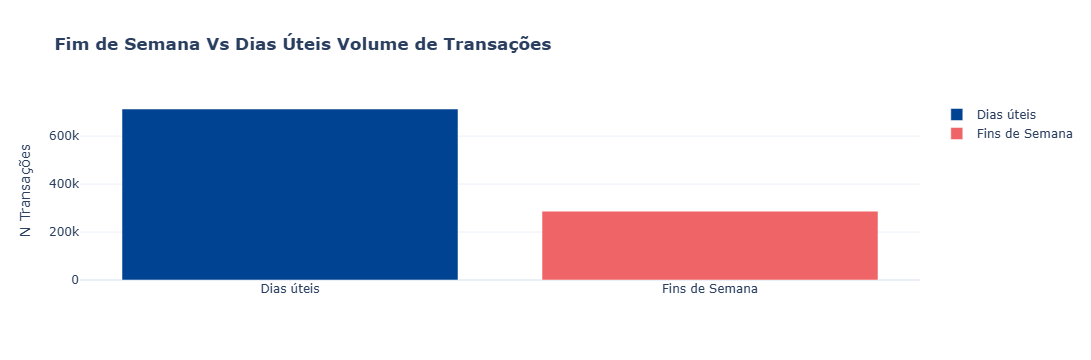

In [9]:
status_geral = df.groupby('is_weekend').agg(
    transacoes=('order_id', 'count'),
    receita=('total_price_usd', 'sum'),
    lucro=('profit_usd', 'sum')
).reset_index()


labels_weekday = 'Dias úteis'
labels_weekend = 'Fins de Semana'

fig = go.Figure()

fig.add_trace(go.Bar(
    x=[labels_weekday],
    y=status_geral[status_geral['is_weekend'] == 'No']['transacoes'].values,
    name='Dias úteis',
    marker_color='#004393'
))

fig.add_trace(go.Bar(
    x=[labels_weekend],
    y=status_geral[status_geral['is_weekend'] == 'Yes']['transacoes'].values,
    name='Fins de Semana',
    marker_color='#EF6567'
))

fig.update_layout(
    title='<b>Fim de Semana Vs Dias Úteis Volume de Transações</b>',
    yaxis_title='N Transações',
    template='plotly_white'
)

fig.show()

<div id="perfil"></div>

## 4. Perfil do Cliente

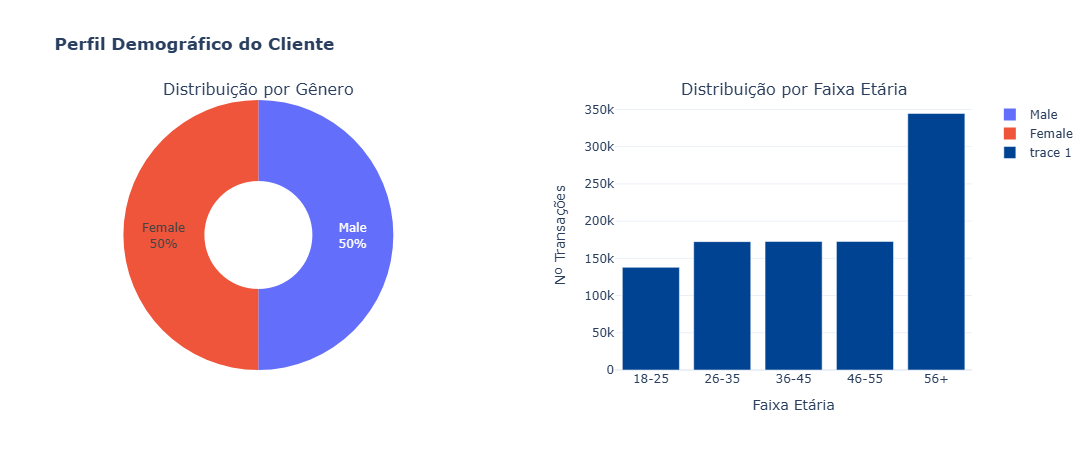

In [10]:
# Perfil do Cliente

# Faixa etária
df['faixa_etaria'] = pd.cut(
    df['age'],
    bins=[17, 25, 35, 45, 55, 100],
    labels=['18-25', '26-35', '36-45', '46-55', '56+']
)

genero = df['gender'].value_counts()
faixa = df['faixa_etaria'].value_counts().reindex(['18-25', '26-35', '36-45', '46-55', '56+'])

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Distribuição por Gênero', 'Distribuição por Faixa Etária'),
    horizontal_spacing=0.2,
    specs=[[{'type': 'pie'}, {'type': 'xy'}]]
)
fig.add_trace(
    go.Pie(labels=genero.index, values=genero.values, hole=0.4,
           textinfo='label+percent'),
    row=1, col=1
)
fig.add_trace(
    go.Bar(x=faixa.index, y=faixa.values, marker_color='#004393'),
    row=1, col=2
)
fig.update_layout(
    title='<b>Perfil Demográfico do Cliente</b>',
    template='plotly_white',
    height=450
)
fig.update_xaxes(title_text='Faixa Etária', row=1, col=2)
fig.update_yaxes(title_text='Nº Transações', row=1, col=2)
fig.show()


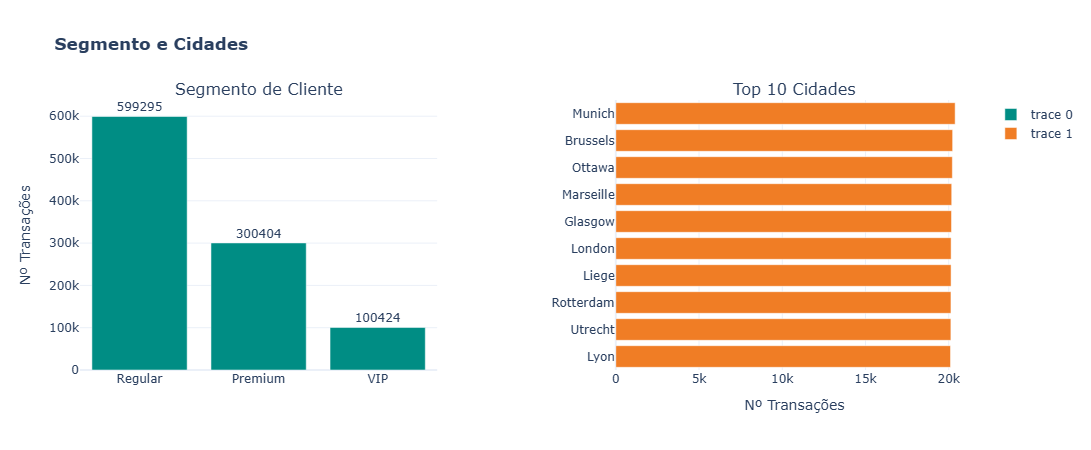

In [11]:
# Segmento de cliente e principais cidades

segmento = df['customer_segment'].value_counts()
top_cidades = df['city'].value_counts().head(10).iloc[::-1]

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Segmento de Cliente', 'Top 10 Cidades'),
    horizontal_spacing=0.2
)
fig.add_trace(
    go.Bar(x=segmento.index, y=segmento.values, marker_color='#008D84',
           text=segmento.values, textposition='outside'),
    row=1, col=1
)
fig.add_trace(
    go.Bar(x=top_cidades.values, y=top_cidades.index, orientation='h',
           marker_color='#F07D25'),
    row=1, col=2
)
fig.update_layout(
    title='<b>Segmento e Cidades</b>',
    template='plotly_white',
    height=450
)
fig.update_yaxes(title_text='Nº Transações', row=1, col=1)
fig.update_xaxes(title_text='Nº Transações', row=1, col=2)
fig.show()


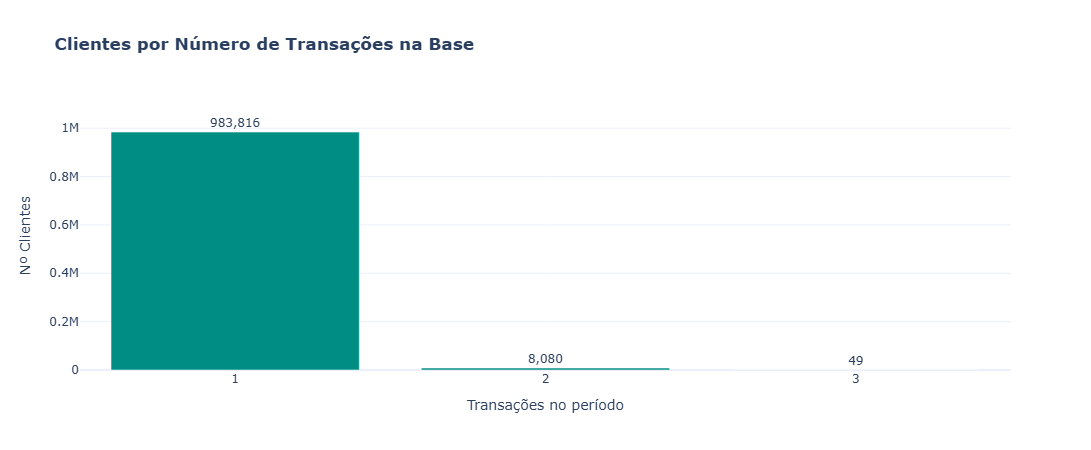

Clientes com mais de 1 transação: 8,129 (0.82% da base)
Coluna total_orders_by_customer (histórico): média 25.5, máx 50 — valores sintéticos, acima do observado no período


In [12]:
# Clientes recorrentes
trans_por_cliente = df['customer_id'].value_counts()
distribuicao = trans_por_cliente.value_counts().sort_index()
n_recorrentes = int((trans_por_cliente > 1).sum())

fig = go.Figure()
fig.add_trace(go.Bar(
    x=distribuicao.index.astype(str),
    y=distribuicao.values,
    marker_color='#008D84',
    text=[f'{v:,}' for v in distribuicao.values],
    textposition='outside'
))
fig.update_layout(
    title='<b>Clientes por Número de Transações na Base</b>',
    xaxis_title='Transações no período',
    yaxis_title='Nº Clientes',
    template='plotly_white',
    height=450
)
fig.show()

print(f"Clientes com mais de 1 transação: {n_recorrentes:,} ({n_recorrentes / trans_por_cliente.size * 100:.2f}% da base)")
print(f"Coluna total_orders_by_customer (histórico): média {df['total_orders_by_customer'].mean():.1f}, máx {df['total_orders_by_customer'].max()} — valores sintéticos, acima do observado no período")

<div id="produtos"></div>

## 5. Produtos & Devoluções


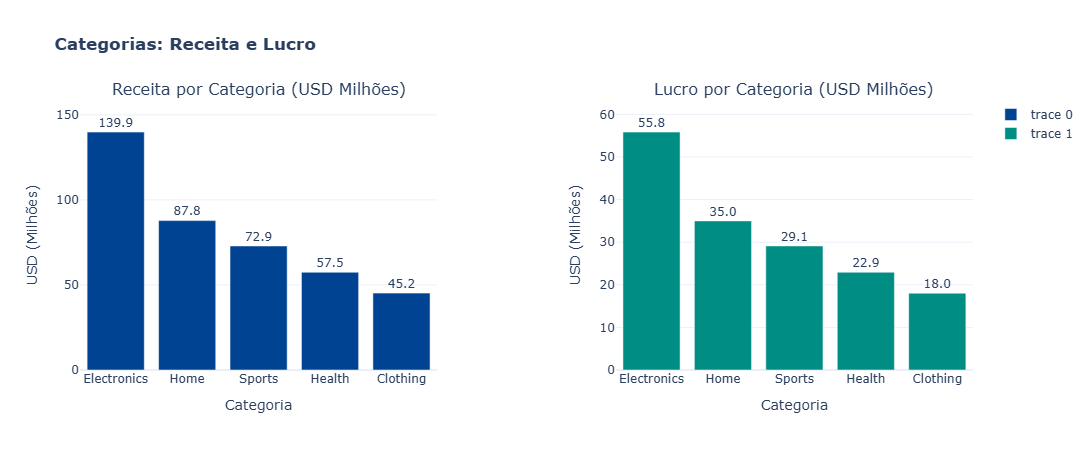

Electronics lidera com 34.7% da receita (US$139.9M) e US$55.8M de lucro


In [13]:
# Receita e lucro por categoria
cat = df.groupby('category').agg(
    receita=('total_price_usd', 'sum'),
    lucro=('profit_usd', 'sum'),
    transacoes=('order_id', 'count')
).sort_values('receita', ascending=False)
cat['pct_receita'] = cat['receita'] / df['total_price_usd'].sum() * 100

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Receita por Categoria (USD Milhões)', 'Lucro por Categoria (USD Milhões)'),
    horizontal_spacing=0.2
)

fig.add_trace(
    go.Bar(x=cat.index, y=cat['receita'] / 1e6, marker_color='#004393',
           text=[f'{v:.1f}' for v in cat['receita'] / 1e6], textposition='outside'),
    row=1, col=1
)
fig.add_trace(
    go.Bar(x=cat.index, y=cat['lucro'] / 1e6, marker_color='#008D84',
           text=[f'{v:.1f}' for v in cat['lucro'] / 1e6], textposition='outside'),
    row=1, col=2
)
fig.update_layout(
    title='<b>Categorias: Receita e Lucro</b>',
    template='plotly_white',
    height=450
)
fig.update_xaxes(title_text='Categoria', row=1, col=1)
fig.update_yaxes(title_text='USD (Milhões)', row=1, col=1)
fig.update_xaxes(title_text='Categoria', row=1, col=2)
fig.update_yaxes(title_text='USD (Milhões)', row=1, col=2)
fig.show()

print(f"{cat.index[0]} lidera com {cat['pct_receita'].iloc[0]:.1f}% da receita (US${cat['receita'].iloc[0] / 1e6:.1f}M) e US${cat['lucro'].iloc[0] / 1e6:.1f}M de lucro")

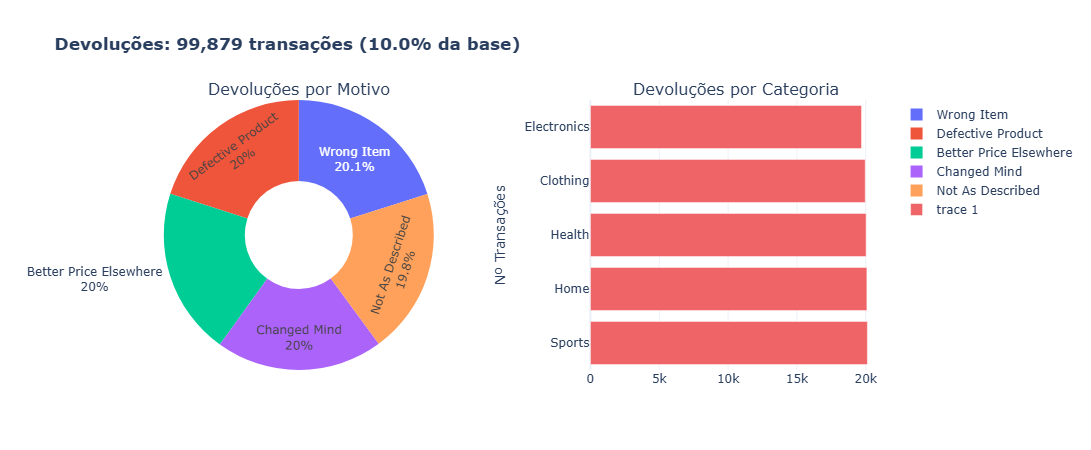

Receita devolvida: US$40.1M | Lucro impactado: US$16.0M


In [14]:
# Devoluções
retornos = df[df['order_status'] == 'Returned']
motivos = retornos['return_reason'].value_counts()
por_categoria = retornos['category'].value_counts()

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Devoluções por Motivo', 'Devoluções por Categoria'),
    specs=[[{'type': 'domain'}, {'type': 'xy'}]],
    horizontal_spacing=0.2
)

fig.add_trace(
    go.Pie(labels=motivos.index, values=motivos.values, hole=0.4,
           textinfo='label+percent'),
    row=1, col=1
)
fig.add_trace(
    go.Bar(x=por_categoria.values, y=por_categoria.index, orientation='h',
           marker_color='#EF6567'),
    row=1, col=2
)
fig.update_layout(
    title=f'<b>Devoluções: {len(retornos):,} transações ({len(retornos) / len(df) * 100:.1f}% da base)</b>',
    template='plotly_white',
    height=450
)
fig.update_yaxes(title_text='Nº Transações', row=1, col=2)
fig.show()

print(f"Receita devolvida: US${retornos['total_price_usd'].sum() / 1e6:.1f}M | Lucro impactado: US${retornos['profit_usd'].sum() / 1e6:.1f}M")

<div id="entrega"></div>

## 6. Entrega & Experiência


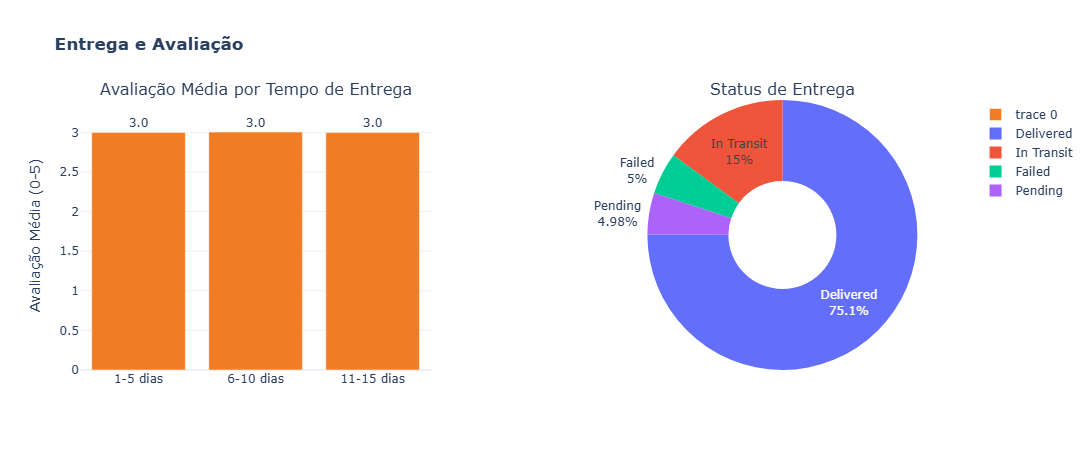

Correlação entre delivery_days e rating: r = -0.0006 (praticamente nula)


In [15]:
# Entrega e avaliação
df['tempo_entrega'] = pd.cut(df['delivery_days'], bins=[0, 5, 10, 15],
                             labels=['1-5 dias', '6-10 dias', '11-15 dias'])
rating_entrega = df.groupby('tempo_entrega', observed=False)['rating'].mean()

status_entrega = df['delivery_status'].value_counts()

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Avaliação Média por Tempo de Entrega', 'Status de Entrega'),
    specs=[[{'type': 'xy'}, {'type': 'domain'}]],
    horizontal_spacing=0.2
)

fig.add_trace(
    go.Bar(x=rating_entrega.index.astype(str), y=rating_entrega.values,
           marker_color='#F07D25',
           text=rating_entrega.values.round(2).astype(str), textposition='outside'),
    row=1, col=1
)
fig.add_trace(
    go.Pie(labels=status_entrega.index, values=status_entrega.values, hole=0.4,
           textinfo='label+percent'),
    row=1, col=2
)
fig.update_layout(
    title='<b>Entrega e Avaliação</b>',
    template='plotly_white',
    height=450
)
fig.update_yaxes(title_text='Avaliação Média (0-5)', row=1, col=1)
fig.show()

corr = df['delivery_days'].corr(df['rating'])
print(f"Correlação entre delivery_days e rating: r = {corr:.4f} (praticamente nula)")

<div id="pagamento"></div>

## 7. Pagamento & Geografia


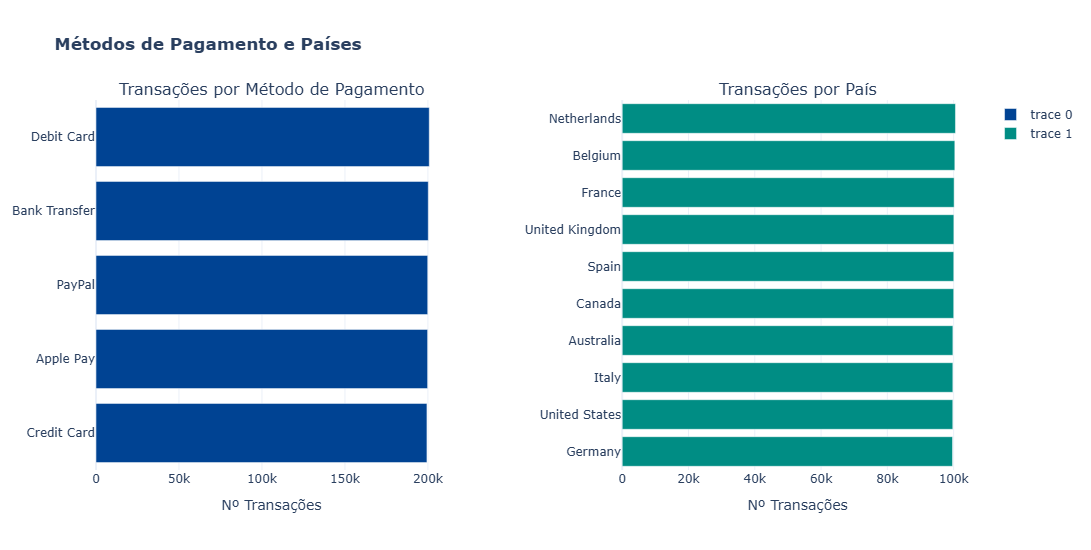

Distribuição praticamente uniforme (~20% por método, ~10% por país) — mais um sinal de base sintética


In [16]:
# Métodos de pagamento e países
pagamento = df.groupby('payment_method').agg(
    transacoes=('order_id', 'count'),
    receita=('total_price_usd', 'sum')
).sort_values('transacoes', ascending=True)

paises = df.groupby('country').agg(
    transacoes=('order_id', 'count'),
    receita=('total_price_usd', 'sum')
).sort_values('transacoes', ascending=True)

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Transações por Método de Pagamento', 'Transações por País'),
    horizontal_spacing=0.2
)

fig.add_trace(
    go.Bar(x=pagamento['transacoes'], y=pagamento.index, orientation='h',
           marker_color='#004393'),
    row=1, col=1
)
fig.add_trace(
    go.Bar(x=paises['transacoes'], y=paises.index, orientation='h',
           marker_color='#008D84'),
    row=1, col=2
)
fig.update_layout(
    title='<b>Métodos de Pagamento e Países</b>',
    template='plotly_white',
    height=550
)
fig.update_xaxes(title_text='Nº Transações', row=1, col=1)
fig.update_xaxes(title_text='Nº Transações', row=1, col=2)
fig.show()

print("Distribuição praticamente uniforme (~20% por método, ~10% por país) — mais um sinal de base sintética")

<div id="insights"></div>

## 8. Insights e Recomendações

1. **2025 é o ano de pico**: $201.6M em receita e $80.5M em lucro (500K transações), acima de 2024 ($183.5M / $73.2M). 2026 é parcial (até fev/2026): $18.2M — não comparar diretamente.
2. **Só 70% das transações é Completed** (receita $282.6M, lucro $112.8M). O total de $403.3M inclui Pending, Processing, Returned e Cancelled — KPIs financeiros devem ser lidos por status.
3. **Sazonalidade praticamente plana**: receita mensal entre $34.3M e $34.4M (típico de base sintética); em dados reais, campanhas e estoques deveriam seguir picos sazonais.
4. **Dias úteis concentram 71.3% do volume e da receita**: priorizar operação e logística nos dias úteis.
5. **Perfil balanceado**: 50/50 entre gêneros; segmentos Regular/Premium/VIP em ~60/30/10. Premium+VIP = 40% das transações e $161.6M de receita (40.1%), a base natural de um programa de fidelidade.
6. **Electronics lidera** com 34.7% da receita ($139.9M) e do lucro ($55.8M); Clothing fecha (11.2%).
7. **Devoluções ~10% ($40.1M de receita)** com distribuição quase uniforme entre motivos (Wrong Item à frente, ~20K) e categorias (Sports à frente) — a homogeneidade em si é sinal de base sintética; em dados reais a análise de causa apontaria produtos específicos.
8. **Entrega não afeta avaliação**: r ≈ -0.0006 e avaliação média estável (~3.0) em todas as faixas de tempo — relação artificial na base sintética.
9. **order_id não é único**: 8.140 IDs colidem apontando para clientes distintos, artefato do gerador de IDs; o grão continua sendo 1 linha = 1 transação.

**Recomendações**: 
- (a) definir KPIs de receita/lucro por status, com foco em Completed
- (b) lançar programa de fidelidade para Premium/VIP
- (c) dimensionar logística e atendimento para os dias úteis
- (d) investigar causas de devolução apenas em dataset real.


<div id="encerramento"></div>

## 9. Encerramento

Base sintética de 1M de registros: útil para praticar manipulação e visualização em escala, mas com padrões homogêneos (sazonalidade plana, 50/50 de gênero, entrega sem relação com avaliação, devoluções uniformes) que limitam os insights. As verificações de consistência (order_id repetido, is_weekend, nulos condicionais) contam tanto quanto a própria análise: são elas que definem quais KPIs podem ser confiados. Para aprofundar, vale repetir a análise em um dataset real, como o feito em [02-ecommerce-uk](../02-ecommerce-uk/).

**Github**: [victorxavier01](https://github.com/victorxavier01) 

**LinkedIn**: [Victor Xavier](https://www.linkedin.com/in/victor-xavier-89a339378/) 

**Medium**: [medium.com/@lvsxmk23](https://medium.com/@lvsxmk23)
